(tutorials-optimization-taylor-polycrystal)=
# A Taylor polycrystal: calibrating slip anisotropy with reorientation

This tutorial calibrates the **slip-system anisotropy** of a crystal-plasticity
**Taylor polycrystal** from synthetic data, through the pyzag chunked adjoint:

1. **The model** — forest-dislocation hardening whose per-slip forest density is
   coupled across systems by a **latent-hardening interaction matrix** $h$
   ([](models-DislocationInteractionStrengthMap)). Each grain also **reorients**
   ([](models-OrientationRate)), so the macroscopic response and the final texture
   both carry information about $h$.
2. **Native vs pyzag** — the same coupled step solved by the built-in
   `TransientDriver` and by pyzag's `solve_adjoint` agree to solver tolerance.
3. **Calibration** — the **latent-hardening ratio** $q$ of a *block-structured*
   interaction matrix (built with `fill = block`: within-slip-family blocks $=1$,
   cross-family blocks $=q$) is recovered from a synthetic experiment. The loss
   combines the **macroscopic stress** curve *and* the **per-grain orientation
   trajectory at every time step** — reorientation is what keeps the anisotropy
   well-conditioned.

Every grain integrates its own elastic strain, orientation, and per-slip
dislocation density while all grains share one global deformation-rate / stress
state — a **BLOCK + DENSE** system (per-grain block unknowns, global mixed-control
dense unknowns) solved with a Schur complement. The per-slip `dislocation_density`
adds a second sub-batch axis, so the coupled step folds **grain × slip**.

In [1]:
# When this notebook runs in Google Colab, install NEML2 from PyPI. The guard
# makes the cell a no-op everywhere else.
import sys

if "google.colab" in sys.modules:
    !pip install -q neml2 pyzag

## The material model

A mixed-control Taylor crystal-plasticity model (FCC, {111}<110> slip): cubic
elasticity, a power-law slip rule, **forest-dislocation hardening with a
slip-system interaction matrix**, and backward-Euler integration of each grain's
elastic strain, orientation, and per-slip dislocation density. The
`interaction_matrix` is built with the [](tensors-SquareMatrix) `[Tensors]` type
using `fill = block` (the Franciosi picture: slip systems grouped into families,
one coefficient per family pair). The calibration replaces it in Python with a
block matrix whose within-family blocks are $1$ and cross-family blocks are the
latent ratio $q$, so a single physical coefficient is fit.

In [2]:
%%writefile model.i
# Mixed-control Taylor crystal plasticity with a slip-system interaction
# (latent-hardening) matrix. The calibrated quantity is the latent scalar q,
# injected in Python as a block matrix (within-family = 1, cross-family = q); the
# [Tensors] hmat below only sets the baseline that NEML2PyzagModel mirrors as a
# trainable parameter.

[Tensors]
  [sdirs]
    type = Python
    expr = 'MillerIndex(torch.tensor([1, 1, 0], dtype=torch.int64))'
  []
  [splanes]
    type = Python
    expr = 'MillerIndex(torch.tensor([1, 1, 1], dtype=torch.int64))'
  []
  [hmat]
    type = SquareMatrix
    fill = block
    blocks = '3 3 3 3'          # 4 slip families of 3 (FCC {111}<110>)
    data = '1 0 0 0  0 1 0 0  0 0 1 0  0 0 0 1'   # baseline; Python sets the latent ratio
  []
[]

[Data]
  [crystal_geometry]
    type = CubicCrystal
    lattice_parameter = 1
    slip_directions = 'sdirs'
    slip_planes = 'splanes'
  []
[]

[Models]
  # Mixed control (global)
  [mixed_control]
    type = MixedControlSetup
    x_above = 'deformation_rate'
    x_below = 'target_cauchy_stress'
    y = 'mixed_state'
  []
  [y_constraint]
    type = SR2LinearCombination
    from = 'mixed_state prescribed'
    to = 'y_residual'
    weights = '1 -1'
  []

  # Per-crystal update
  [euler_rodrigues]
    type = RotationMatrix
    from = 'orientation'
    to = 'orientation_matrix'
  []
  [elastic_tensor]
    type = CubicElasticityTensor
    coefficient_types = 'YOUNGS_MODULUS POISSONS_RATIO SHEAR_MODULUS'
    coefficients = '100000 0.307 11046.58'
  []
  [elasticity]
    type = GeneralElasticity
    elastic_stiffness_tensor = 'elastic_tensor'
    strain = 'elastic_strain'
    stress = 'cauchy_stress'
  []
  [resolved_shear]
    type = ResolvedShear
    stress = 'cauchy_stress'
  []
  [elastic_stretch]
    type = ElasticStrainRate
    deformation_rate = 'deformation_rate'
  []
  [plastic_spin]
    type = PlasticVorticity
  []
  [plastic_deformation_rate]
    type = PlasticDeformationRate
  []
  [orientation_rate]
    type = OrientationRate
  []
  [sum_slip_rates]
    type = SumSlipRates
  []
  [slip_rule]
    type = PowerLawSlipRule
    n = 8.0
    gamma0 = 2.0e-1
  []
  [slip_strength]
    type = DislocationInteractionStrengthMap
    dislocation_density = 'dislocation_density'
    interaction_matrix = 'hmat'
    alpha = 0.3
    mu = 1.0e5
    b = 1.0e-4
    constant_strength = 50.0
  []
  [dislocation_density_rate]
    type = PerSlipForestDislocationEvolution
    dislocation_density = 'dislocation_density'
    k1 = 1e2
    k2 = 40.0
  []
  [integrate_dislocation_density]
    type = ScalarBackwardEulerTimeIntegration
    variable = 'dislocation_density'
  []
  [integrate_elastic_strain]
    type = SR2BackwardEulerTimeIntegration
    variable = 'elastic_strain'
  []
  [integrate_orientation]
    type = WR2ImplicitExponentialTimeIntegration
    variable = 'orientation'
  []
  [per_crystal_update]
    type = ComposedModel
    models = 'elasticity euler_rodrigues
              orientation_rate resolved_shear
              elastic_stretch
              plastic_deformation_rate plastic_spin
              sum_slip_rates slip_rule slip_strength dislocation_density_rate
              integrate_dislocation_density
              integrate_elastic_strain
              integrate_orientation'
    additional_outputs = 'cauchy_stress'
  []

  # Global constraint
  [mean_stress]
    type = SR2IntermediateMean
    from = 'cauchy_stress'
    to = 'mean_cauchy_stress'
    reduces = 'grain'
  []
  [match_mean_cauchy_stress]
    type = SR2LinearCombination
    from = 'target_cauchy_stress mean_cauchy_stress'
    to = 'target_cauchy_stress_residual'
    weights = '1 -1'
  []
  [global_constraint]
    type = ComposedModel
    models = 'mean_stress match_mean_cauchy_stress'
  []

  # Full implicit model
  [implicit_model]
    type = ComposedModel
    models = 'mixed_control y_constraint per_crystal_update global_constraint'
  []
[]

[EquationSystems]
  [eq_sys]
    type = NonlinearSystem
    model = 'implicit_model'
    unknowns = 'elastic_strain orientation dislocation_density; deformation_rate target_cauchy_stress'
    residuals = 'elastic_strain_residual orientation_residual dislocation_density_residual; y_residual target_cauchy_stress_residual'
    structure = 'block dense'
  []
[]

[Solvers]
  [newton]
    type = NewtonWithLineSearch
    max_linesearch_iterations = 5
    linear_solver = 'schur'
  []
  [lu]
    type = DenseLU
  []
  [schur]
    type = SchurComplement
    residual_primary_group = '0'
    unknown_primary_group = '0'
    primary_solver = 'lu'
    schur_solver = 'lu'
  []
[]

[Models]
  [predictor]
    type = ConstantExtrapolationPredictor
    unknowns_SR2 = 'elastic_strain deformation_rate target_cauchy_stress'
    unknowns_MRP = 'orientation'
    unknowns_Scalar = 'dislocation_density'
  []
  [model_bare]
    type = ImplicitUpdate
    equation_system = 'eq_sys'
    solver = 'newton'
    predictor = 'predictor'
  []
  [compute_mixed_state]
    type = MixedControlSetup
    x_above = 'deformation_rate'
    x_below = 'target_cauchy_stress'
    y = 'mixed_state'
  []
  [model]
    type = ComposedModel
    models = 'model_bare compute_mixed_state'
    additional_outputs = 'mixed_state'
  []
[]

Overwriting model.i


## Setup

Imports, the calibration configuration, and the reproducibility knobs. The
calibrated parameter is the mirrored interaction matrix; a `torch.nn.utils`
parametrization makes the scalar $q$ its only free degree of freedom.

In [3]:
import matplotlib.pyplot as plt
import torch
from torch.nn.utils import parametrize
from pyzag import chunktime, nonlinear

import neml2
import neml2.types
import neml2.texture as texture
from neml2.pyzag import NEML2PyzagModel

torch.manual_seed(42)
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

# Kept small so the tutorial runs quickly; scale these up for real work.
NGRAINS = 12
NTIME = 50
NCHUNK = 5
N_ITER = 5
MAX_STRAIN = 0.05
RATE = 1.0e-3
AXIAL = 2  # axial component in the 6-vector Mandel state
NSLIP = 12  # FCC {111}<110> slip systems
STRIDE = 6 + 3 + NSLIP  # per-grain state block: elastic_strain(6) + MRP(3) + dd(12)
INIT_RHO = 10.0  # initial per-slip dislocation density

# The interaction matrix is the calibrated parameter; a parametrization reduces it
# to one latent-hardening ratio q (within-family blocks = 1, cross-family = q).
CALIBRATION_PARAMS = ["slip_strength_interaction_matrix"]
BLOCKS = [3, 3, 3, 3]  # slip-family partition for the block interaction matrix (sums to NSLIP)
Q_TRUTH = 0.4  # ground-truth latent-hardening ratio (cross-family coefficient)
Q_INIT = 0.1  # deliberately-wrong starting guess (>= 0 so the forest sum stays >= 0)

# Loss weights (each term is normalized by its target magnitude in the closure).
W_STRESS = 1.0
W_TEXTURE = 1.0

## A synthetic experiment

We draw random uniform-on-SO(3) grain orientations (as MRPs, the model's
orientation parametrization) and a constant-rate axial strain ramp.

In [4]:
def random_orientations(ngrains):
    g = torch.randn(ngrains, 3, 3)
    q, r = torch.linalg.qr(g)
    q = q * torch.sign(torch.diagonal(r, dim1=-2, dim2=-1)).unsqueeze(-2)
    q[:, :, 0] = q[:, :, 0] * torch.linalg.det(q).unsqueeze(-1)
    return neml2.types.MRP.from_matrix(neml2.types.R2(q, 1))


def strain_time_grid(max_strain, ntime, rate):
    strain = torch.linspace(0.0, max_strain, ntime)
    return strain, strain / rate


orientations = random_orientations(NGRAINS)
strain, times = strain_time_grid(MAX_STRAIN, NTIME, RATE)

## Wrap the model for pyzag, with $q$ as the only free parameter

`NEML2PyzagModel` mirrors the `interaction_matrix` as a trainable
`torch.nn.Parameter` of shape `(NSLIP, NSLIP)`. We then register a `torch.nn.utils`
parametrization so the matrix is *computed* from a single latent-hardening ratio
`q`: within-family blocks are $1$ (self + coplanar systems) and cross-family blocks
are $q$. The optimizer only ever sees `q` — low-dimensional and well-posed, and
(with `q >= 0`) the forest sum stays non-negative so the $\sqrt{\cdot}$ is real.
Normalizing the self-block to $1$ is the standard latent-hardening convention (two
free block coefficients are degenerate when the dislocation density is nearly
uniform across systems). `neml2.compile` JIT-compiles the residual/Jacobian in
place.

In [5]:
class BlockLatent(torch.nn.Module):
    # Latent ratio q -> (NSLIP, NSLIP): within-family blocks = 1 (self + coplanar),
    # cross-family blocks = q. The ``fill = block`` structure, as a function of q.
    def __init__(self, blocks, q_init):
        super().__init__()
        self.register_buffer("blocks_t", torch.tensor(blocks))
        self.register_buffer("eye", torch.eye(len(blocks)))
        self.q_init = q_init

    def forward(self, q):
        coeffs = self.eye + q * (1.0 - self.eye)  # per-family-pair coefficients
        return coeffs.repeat_interleave(self.blocks_t, 0).repeat_interleave(self.blocks_t, 1)

    def right_inverse(self, h):
        # Sets the stored scalar when the parametrization is registered.
        return torch.tensor(float(self.q_init))


nsys = neml2.load_nonlinear_system("model.i", "eq_sys")
model = NEML2PyzagModel(nsys, include_parameters=CALIBRATION_PARAMS)
# q starts at the ground truth; the native run below is compared at this same q.
parametrize.register_parametrization(
    model, "slip_strength_interaction_matrix", BlockLatent(BLOCKS, Q_TRUTH)
)
q_param = model.parametrizations.slip_strength_interaction_matrix.original
neml2.compile(model)

ParametrizedNEML2PyzagModel(
  (parametrizations): ModuleDict(
    (slip_strength_interaction_matrix): ParametrizationList(
      (0): BlockLatent()
    )
  )
)

## The differentiable module

A thin `torch.nn.Module` that assembles the initial state and the per-step driving
forces once, then returns **both** the macroscopic axial stress trajectory and the
**per-grain orientation at every time step** (the reorientation history).
`forward` differentiates through the chunked solve with `nonlinear.solve_adjoint`.
Orientation is read from the grain-major state vector — each grain's block is
`[elastic_strain(6), orientation(3), dislocation_density(NSLIP)]` — at all steps.

In [6]:
class CrystalCalibration(torch.nn.Module):
    def __init__(self, model, orientations, strain, times, nchunk):
        super().__init__()
        self.model = model
        self.nchunk = nchunk
        self.orientations = orientations
        self.register_buffer("strain", strain)

        ngrains = orientations.shape[0]
        ntime = strain.shape[0]
        dtype = orientations.dtype
        nbatch = 1
        ic = {
            "elastic_strain": torch.zeros(nbatch, ngrains, 6, dtype=dtype),
            "orientation": orientations.dynamic_batch.unsqueeze(0),
            "dislocation_density": torch.full((nbatch, ngrains, NSLIP), INIT_RHO, dtype=dtype),
            "deformation_rate": torch.zeros(nbatch, 6, dtype=dtype),
            "target_cauchy_stress": torch.zeros(nbatch, 6, dtype=dtype),
        }
        self._y0 = model.assemble_state(ic, dynamic_dim=1)
        self._ngrains = ngrains

        control = torch.zeros(ntime, nbatch, 6, dtype=dtype)
        control[..., AXIAL] = 1.0
        prescribed = torch.zeros(ntime, nbatch, 6, dtype=dtype)
        prescribed[..., AXIAL] = RATE
        forces = {
            "control": control,
            "prescribed": prescribed,
            "t": times.reshape(ntime, 1).expand(ntime, nbatch).contiguous(),
            "vorticity": torch.zeros(ntime, nbatch, 3, dtype=dtype),
        }
        self._forces = model.assemble_forces(forces, dynamic_dim=2)
        self._ntime = ntime

    @property
    def calibration_parameters(self):
        return [self.model.parametrizations.slip_strength_interaction_matrix.original]

    def _solver(self, direct_solve_operator):
        return nonlinear.RecursiveNonlinearEquationSolver(
            self.model,
            step_generator=nonlinear.StepGenerator(self.nchunk),
            predictor=nonlinear.PreviousStepsPredictor(),
            direct_solve_operator=direct_solve_operator,
            nonlinear_solver=chunktime.ChunkNewtonRaphsonLineSearch(
                rtol=1e-6, atol=1e-8, linesearch_iter=5
            ),
        )

    def forward(self, direct_solve_operator=chunktime.BidiagonalThomasFactorization):
        solver = self._solver(direct_solve_operator)
        traj = nonlinear.solve_adjoint(solver, self._y0, self._ntime, self._forces)
        macro_stress = traj[..., -6 + AXIAL].squeeze(-1)
        # Grain-major state; per-grain orientation (MRP) at [6:9], at EVERY step.
        ng = self._ngrains
        ori_traj = traj[..., : ng * STRIDE].reshape(*traj.shape[:-1], ng, STRIDE)[..., 6:9]
        return macro_stress, ori_traj


module = CrystalCalibration(model, orientations, strain, times, NCHUNK).to(device)

## Run it natively

Before differentiating anything, drive the **same** model (at $h = I$, i.e. $q=0$)
through the built-in `TransientDriver`, reusing the very orientations the pyzag
module holds, so the two runs are directly comparable.

In [7]:
ori_literal = repr(orientations.data.detach().cpu().tolist())
_shared_models = "[Models]" + open("model.i").read().split("[Models]", 1)[1]
# native interaction matrix = the block matrix at the ground-truth latent ratio,
# matching the pyzag h we compare against.
_nb = len(BLOCKS)
block_data = " ".join("1" if i == j else repr(Q_TRUTH) for i in range(_nb) for j in range(_nb))

native_input = (
    f"""
[Tensors]
  [sdirs]
    type = Python
    expr = 'MillerIndex(torch.tensor([1, 1, 0], dtype=torch.int64))'
  []
  [splanes]
    type = Python
    expr = 'MillerIndex(torch.tensor([1, 1, 1], dtype=torch.int64))'
  []
  [hmat]
    type = SquareMatrix
    fill = block
    blocks = '3 3 3 3'
    data = '{block_data}'
  []
  [times]
    type = Python
    expr = 'Scalar(torch.linspace(0.0, {MAX_STRAIN / RATE}, {NTIME}, dtype=torch.float64).reshape({NTIME}, 1))'
  []
  [control]
    type = Python
    expr = 'SR2.fill(0.0, 0.0, 1.0, 0.0, 0.0, 0.0).dynamic_batch.expand({NTIME}, 1)'
  []
  [prescribed]
    type = Python
    expr = 'SR2.fill(0.0, 0.0, {RATE}, 0.0, 0.0, 0.0).dynamic_batch.expand({NTIME}, 1)'
  []
  [vorticity]
    type = Python
    expr = 'WR2(torch.zeros({NTIME}, 1, 3, dtype=torch.float64))'
  []
  [initial_orientation]
    type = Python
    expr = 'MRP(torch.tensor({ori_literal}, dtype=torch.float64), sub_batch_ndim=1).sub_batch.retag(1)'
  []
  [initial_elastic_strain]
    type = Python
    expr = 'SR2(torch.zeros({NGRAINS}, 6, dtype=torch.float64), sub_batch_ndim=1).sub_batch.retag(1)'
  []
  [initial_dislocation_density]
    type = Python
    expr = 'Scalar(torch.full(({NGRAINS}, {NSLIP}), {INIT_RHO}, dtype=torch.float64), sub_batch_ndim=2).sub_batch.retag(2)'
  []
[]

[Data]
  [crystal_geometry]
    type = CubicCrystal
    lattice_parameter = 1
    slip_directions = 'sdirs'
    slip_planes = 'splanes'
  []
[]

[Drivers]
  [driver]
    type = TransientDriver
    model = 'model'
    prescribed_time = 'times'
    prescribed_SR2_names = 'prescribed control'
    prescribed_SR2_values = 'prescribed control'
    prescribed_WR2_names = 'vorticity'
    prescribed_WR2_values = 'vorticity'
    ic_MRP_names = 'orientation'
    ic_MRP_values = 'initial_orientation'
    ic_SR2_names = 'elastic_strain'
    ic_SR2_values = 'initial_elastic_strain'
    ic_Scalar_names = 'dislocation_density'
    ic_Scalar_values = 'initial_dislocation_density'
  []
[]

"""
    + _shared_models
)

with open("model_native.i", "w") as fh:
    fh.write(native_input)

driver = neml2.load_input("model_native.i").get_driver("driver")
driver.run()
res = driver.result()
nsteps = driver.nsteps
native_stress = torch.tensor(
    [0.0] + [res[f"output.{i}.z"][..., AXIAL].reshape(-1)[0].item() for i in range(1, nsteps)],
    device=device,
)
print(f"native run: {nsteps} steps, peak axial stress = {native_stress.max().item():.2f} MPa")

native run: 50 steps, peak axial stress = 101.48 MPa


## Same model via pyzag, and compare

At the same block interaction matrix, the pyzag `solve_adjoint` path reproduces the
native implicit driver to solver tolerance — two routes to the same equations.

/home/tranh/.claude_tmp/ipykernel_470980/3744906335.py:41: UserWarning: pyzag lowered torch._functorch.config.donated_buffer's default to False process-wide. AOTAutograd 'donated buffers' (torch>=2.12) are incompatible with pyzag's retain_graph=True adjoint over torch.compile'd models, which otherwise raises 'compiled with non-empty donated buffers'. To keep donated buffers enabled, restore torch._functorch.config._config['donated_buffer'].default = True -- compiled models differentiated through the adjoint will then error.
  return nonlinear.RecursiveNonlinearEquationSolver(


W1008 12:37:52.149000 470980 site-packages/torch/utils/cpp_extension.py:140] [1/0] No CUDA runtime is found, using CUDA_HOME='/usr'


max |native - pyzag| = 5.453e-06 MPa   (relative 5.37e-08)


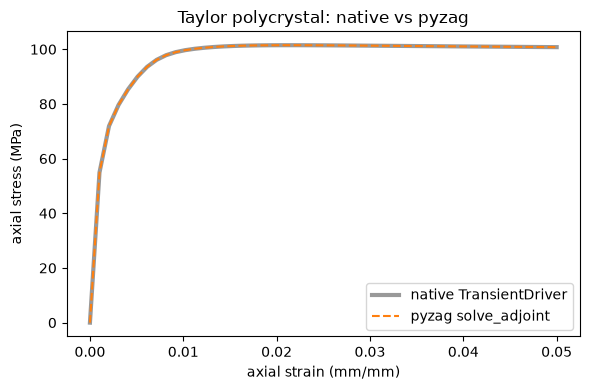

In [8]:
with torch.no_grad():
    q_param.data.fill_(Q_TRUTH)
    model._update_parameter_values()
    pyzag_stress, _ = module()

max_diff = (native_stress - pyzag_stress).abs().max().item()
rel = max_diff / pyzag_stress.abs().max().item()
print(f"max |native - pyzag| = {max_diff:.3e} MPa   (relative {rel:.2e})")
assert rel < 1e-4, "native and pyzag macroscopic responses should agree to solver tolerance"

s = strain.detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    s, native_stress.detach().cpu().numpy(), "k-", lw=3, alpha=0.4, label="native TransientDriver"
)
ax.plot(s, pyzag_stress.detach().cpu().numpy(), "C1--", lw=1.5, label="pyzag solve_adjoint")
ax.set_xlabel("axial strain (mm/mm)")
ax.set_ylabel("axial stress (MPa)")
ax.set_title("Taylor polycrystal: native vs pyzag")
ax.legend()
fig.tight_layout()

## Ground truth and a perturbed start

We set the latent-hardening scalar to its ground-truth value and record the
synthetic experiment — the macroscopic stress curve **and** the final per-grain
texture. Then we move $q$ to a deliberately-wrong starting guess.

In [9]:
with torch.no_grad():
    q_param.data.fill_(Q_TRUTH)
    model._update_parameter_values()
    target_stress, target_texture = module()

with torch.no_grad():
    q_param.data.fill_(Q_INIT)
    model._update_parameter_values()
    init_stress, init_texture = module()

print(f"truth  q = {Q_TRUTH:.3f}")
print(f"start  q = {float(q_param):.3f}")

truth  q = 0.400
start  q = 0.100


/home/tranh/miniconda3/envs/moose-src/lib/python3.13/site-packages/torch/utils/_device.py:122: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  return func(*args, **kwargs)


## Calibrate through the chunked adjoint

We minimize a combined loss: the macroscopic stress mismatch **and** the
final-texture mismatch, each normalized by its target magnitude. The stress term
carries most of $q$'s identifiability; the orientation-trajectory term (every grain
at every step) is a physically meaningful constraint that reorientation makes
available. Each `closure` call backpropagates through the chunked adjoint, so peak
memory scales with the chunk size, not the full time history.

In [10]:
optimizer = torch.optim.LBFGS(
    module.calibration_parameters, lr=0.3, max_iter=20, line_search_fn="strong_wolfe"
)
history = []

s_scale = float((target_stress**2).mean())
t_scale = float((target_texture**2).mean())


def closure():
    optimizer.zero_grad()
    stress, tex = module()
    loss = (
        W_STRESS * ((stress - target_stress) ** 2).mean() / s_scale
        + W_TEXTURE * ((tex - target_texture) ** 2).mean() / t_scale
    )
    loss.backward()
    return loss


for it in range(N_ITER):
    loss = float(optimizer.step(closure).detach())
    history.append(loss)
    print(f"iter {it + 1:2d}  loss = {loss:.6e}   q = {float(q_param):.4f}")

with torch.no_grad():
    final_stress, final_texture = module()
q_recovered = float(q_param)
assert history[-1] < history[0]

iter  1  loss = 5.405515e-03   q = 0.3995


iter  2  loss = 1.007015e-08   q = 0.3999


iter  3  loss = 5.812645e-10   q = 0.3999


iter  4  loss = 2.848540e-10   q = 0.3999


iter  5  loss = 2.848540e-10   q = 0.3999


## Results

The loss drops by orders of magnitude, the latent-hardening ratio returns to the
ground truth, and both the calibrated stress--strain curve and the orientation
history land back on the synthetic target. The inverse pole figures compare the
recovered final texture against the truth.

loss 5.406e-03 -> 2.849e-10
q:  truth = 0.4000   recovered = 0.3999


Text(0.5, 1.0, 'Final texture: calibrated')

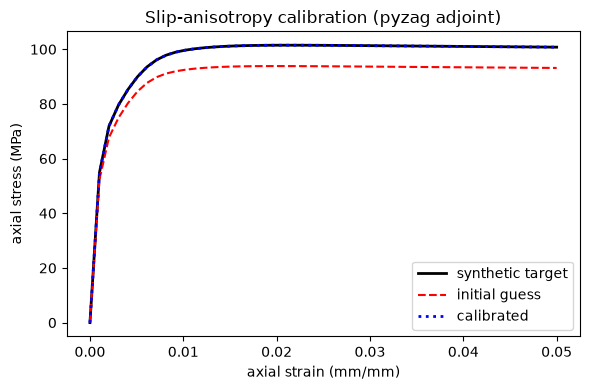

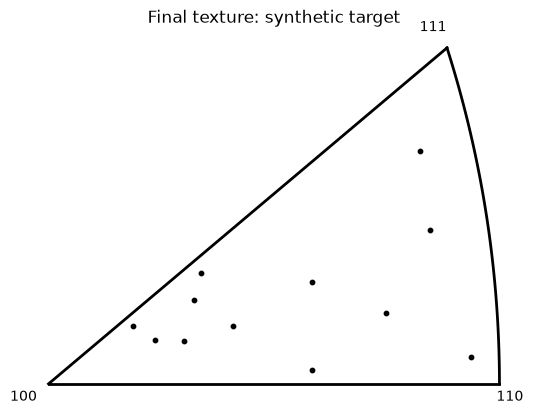

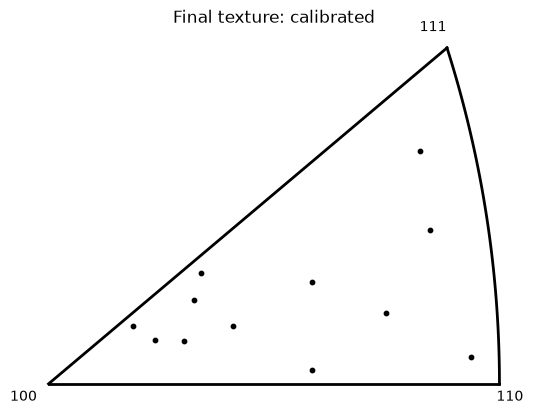

In [11]:
print(f"loss {history[0]:.3e} -> {history[-1]:.3e}")
print(f"q:  truth = {Q_TRUTH:.4f}   recovered = {q_recovered:.4f}")

s = strain.detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(s, target_stress.detach().cpu().numpy(), "k-", lw=2, label="synthetic target")
ax.plot(s, init_stress.detach().cpu().numpy(), "r--", label="initial guess")
ax.plot(s, final_stress.detach().cpu().numpy(), "b:", lw=2, label="calibrated")
ax.set_xlabel("axial strain (mm/mm)")
ax.set_ylabel("axial stress (MPa)")
ax.set_title("Slip-anisotropy calibration (pyzag adjoint)")
ax.legend()
fig.tight_layout()

# Final-texture comparison: inverse pole figures (loading direction).
loading = torch.tensor([0.0, 0.0, 1.0], device=device)
tgt = neml2.types.MRP(target_texture[-1].reshape(-1, 3))  # final-step texture
cal = neml2.types.MRP(final_texture[-1].reshape(-1, 3))
texture.pretty_plot_inverse_pole_figure(tgt, loading, crystal_symmetry="432")
plt.title("Final texture: synthetic target")
texture.pretty_plot_inverse_pole_figure(cal, loading, crystal_symmetry="432")
plt.title("Final texture: calibrated")

## Where to go next

- The scalar-viscoplastic versions of this calibration workflow are the
  [deterministic](../deterministic/main) and [statistical](../statistical/main)
  notebooks.
- To *run* a slip-anisotropy model and compare ways of specifying the interaction
  matrix (diagonal, block, dense), see the crystal-plasticity module's
  [slip-anisotropy example](../../../modules/solid_mechanics/crystal_plasticity/slip_anisotropy).
- The [pyzag tutorial](tutorials-optimization-pyzag) explains *why* the chunked
  adjoint is needed for time-history calibration.